# Campus Wall Decoration — ResNet50 Baseline

ResNet50-only baseline for `wall_type` and `indoor` classification.

**Two methods, both reported on the held-out `test.csv`:**
1. **Frozen-feature** — ResNet50 (ImageNet pretrained, no fine-tuning) + Logistic Regression / Linear SVM / KNN.
2. **Fine-tuned** — ResNet50 with a trainable classification head, end-to-end.



In [ ]:
# ============================================================
# 1. INSTALL + IMPORTS
# ============================================================

!pip -q install torch torchvision scikit-learn pandas numpy matplotlib seaborn pillow

import os
import glob
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from PIL import Image

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [ ]:
# ============================================================
# 2. CONFIG
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Folder containing train.csv / validation.csv / test.csv
SPLITS_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset"

# Folder that actually contains the image files right now (image_002.jpeg, image_024.jpg, ...).
RAW_IMAGES_FOLDER = "/content/drive/MyDrive/Wall decoration images"

OUTPUT_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results/ResNet50"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LR = 1e-4

TASKS = {"wall_type": "multiclass", "indoor": "binary"}


Mounted at /content/drive


## Load splits and re-resolve image paths

Loads the annotation columns from your real CSVs, then rebuilds `image_path` fresh against
`RAW_IMAGES_FOLDER`, matching by `image_id` regardless of the original file extension/case
(your data has a mix of `.jpg` / `.jpeg` / `.JPG`).


In [ ]:
# ============================================================
# 3. LOAD SPLIT CSVs
# ============================================================

def load_split(name):
    path = os.path.join(SPLITS_FOLDER, name)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find {path}\nCheck SPLITS_FOLDER in the CONFIG cell."
        )
    df = pd.read_csv(path, encoding="utf-8-sig")
    keep = ["image_id", "wall_type", "indoor", "description_en",
            "description_bn", "color_idea", "group_id"]
    return df[[c for c in keep if c in df.columns]].copy()

train_df = load_split("train.csv")
val_df   = load_split("validation.csv")
test_df  = load_split("test.csv")

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("\nwall_type classes present per split:")
print("  train:", sorted(train_df['wall_type'].unique()))
print("  val:  ", sorted(val_df['wall_type'].unique()))
print("  test: ", sorted(test_df['wall_type'].unique()))


Train: 171 | Val: 8 | Test: 25

wall_type classes present per split:
  train: ['backdrop_board', 'brick_wall', 'bulletin_board', 'painted_wall', 'wooden_wall']
  val:   ['backdrop_board', 'brick_wall', 'painted_wall', 'wooden_wall']
  test:  ['backdrop_board', 'brick_wall', 'bulletin_board', 'painted_wall', 'wooden_wall']


In [ ]:
# ============================================================
# 4. RE-RESOLVE IMAGE PATHS (case/extension-robust)
# ============================================================

EXTENSIONS = [".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG", ".webp", ".WEBP"]

def resolve_image_path(image_id):
    for ext in EXTENSIONS:
        candidate = os.path.join(RAW_IMAGES_FOLDER, image_id + ext)
        if os.path.exists(candidate):
            return candidate
    matches = glob.glob(os.path.join(RAW_IMAGES_FOLDER, image_id + ".*"))
    return matches[0] if matches else None

def attach_image_paths(df):
    df = df.copy()
    df["image_path"] = df["image_id"].apply(resolve_image_path)
    missing = df[df["image_path"].isna()]
    if len(missing) > 0:
        print(f"⚠️  {len(missing)} images not found in RAW_IMAGES_FOLDER (dropped): "
              f"{missing['image_id'].tolist()}")
    return df[df["image_path"].notna()].reset_index(drop=True)

train_df = attach_image_paths(train_df)
val_df   = attach_image_paths(val_df)
test_df  = attach_image_paths(test_df)

for d in (train_df, val_df, test_df):
    d["indoor"] = pd.to_numeric(d["indoor"], errors="coerce").astype(int)

print("After path resolution -> Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))


After path resolution -> Train: 171 | Val: 8 | Test: 25


## Merge train + validation for training

Given `validation.csv`'s size (8 images, missing a class), it's merged into the training pool
for both the frozen-feature classifiers and fine-tuning. `test.csv` (25 images) is the only
data used for reported metrics below.


In [ ]:
# ============================================================
# 5. TRAIN POOL = train + validation
# ============================================================

train_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print("Train pool:", len(train_pool_df), "| Test (held out):", len(test_df))

wall_type_encoder = LabelEncoder()
wall_type_encoder.fit(train_pool_df["wall_type"])

for d in (train_pool_df, test_df):
    d["wall_type_label"] = wall_type_encoder.transform(d["wall_type"])

WALL_TYPE_CLASSES = list(wall_type_encoder.classes_)
NUM_WALL_TYPES = len(WALL_TYPE_CLASSES)
print("wall_type classes:", WALL_TYPE_CLASSES)

TARGET_COLUMN = {"wall_type": "wall_type_label", "indoor": "indoor"}
NUM_CLASSES = {"wall_type": NUM_WALL_TYPES, "indoor": 2}


Train pool: 179 | Test (held out): 25
wall_type classes: ['backdrop_board', 'brick_wall', 'bulletin_board', 'painted_wall', 'wooden_wall']


In [ ]:
# ============================================================
# 6. DATASET + TRANSFORMS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class WallDecorationDataset(Dataset):
    def __init__(self, dataframe, target_column, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            image = img.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row[self.target_column])


## Naive baseline (majority class)

In [ ]:
# ============================================================
# 7. NAIVE MAJORITY-CLASS BASELINE
# ============================================================

results = []

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    majority_class = train_pool_df[target_column].mode()[0]
    y_true = test_df[target_column].values
    y_pred = np.full_like(y_true, fill_value=majority_class)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    results.append({"task": task, "method": "naive_majority", "accuracy": acc, "macro_f1": f1_macro})
    print(f"[naive] {task:10s} test acc={acc:.3f} macro_f1={f1_macro:.3f}")


[naive] wall_type  test acc=0.480 macro_f1=0.130
[naive] indoor     test acc=0.920 macro_f1=0.479


## Baseline 1 — ResNet50 frozen-feature + classical classifiers

In [ ]:
# ============================================================
# 8. RESNET50 FEATURE EXTRACTOR
# ============================================================

def get_resnet50_feature_extractor():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    feature_dim = model.fc.in_features   # 2048
    model.fc = nn.Identity()
    return model.to(DEVICE).eval(), feature_dim


@torch.no_grad()
def extract_features(backbone_model, dataframe, target_column, batch_size=16):
    dataset = WallDecorationDataset(dataframe, target_column, transform=eval_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    all_features, all_labels = [], []
    for images, labels in loader:
        feats = backbone_model(images.to(DEVICE))
        all_features.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_features), np.concatenate(all_labels)


resnet_extractor, feature_dim = get_resnet50_feature_extractor()
print("ResNet50 pooled feature dim:", feature_dim)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 46.0MB/s]


ResNet50 pooled feature dim: 2048


In [ ]:
# ============================================================
# 9. EXTRACT FEATURES + FIT CLASSICAL CLASSIFIERS
# ============================================================

def get_classical_classifiers():
    return {
        "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
        "linear_svm": SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_SEED),
        "knn": KNeighborsClassifier(n_neighbors=5),
    }

frozen_feature_cache = {}

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    X_train, y_train = extract_features(resnet_extractor, train_pool_df, target_column, BATCH_SIZE)
    X_test,  y_test  = extract_features(resnet_extractor, test_df,       target_column, BATCH_SIZE)
    frozen_feature_cache[task] = {"train": (X_train, y_train), "test": (X_test, y_test)}
    print(f"\n{task}: train features {X_train.shape}, test features {X_test.shape}")

    for clf_name, clf in get_classical_classifiers().items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
        results.append({"task": task, "method": f"frozen_resnet50_{clf_name}", "accuracy": acc, "macro_f1": f1_macro})
        print(f"  [frozen+{clf_name:10s}] acc={acc:.3f} macro_f1={f1_macro:.3f}")



wall_type: train features (179, 2048), test features (25, 2048)
  [frozen+logreg    ] acc=0.760 macro_f1=0.693
  [frozen+linear_svm] acc=0.800 macro_f1=0.726
  [frozen+knn       ] acc=0.680 macro_f1=0.408

indoor: train features (179, 2048), test features (25, 2048)
  [frozen+logreg    ] acc=0.960 macro_f1=0.889
  [frozen+linear_svm] acc=0.960 macro_f1=0.889
  [frozen+knn       ] acc=0.920 macro_f1=0.479


## Baseline 2 — ResNet50 fine-tuned end-to-end

Trained on `train_pool_df` (train+validation merged) with a class-weighted loss for
`FINE_TUNE_EPOCHS` fixed epochs, then evaluated once on `test_df`.


In [11]:
# ============================================================
# 10. FINE-TUNE RESNET50
# ============================================================

def build_resnet50_classifier(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def compute_class_weights(df, target_column, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=df[target_column].values)
    return torch.tensor(weights, dtype=torch.float32)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), acc, f1_macro


def finetune_resnet50(task):
    target_column = TARGET_COLUMN[task]
    num_classes = NUM_CLASSES[task]

    train_ds = WallDecorationDataset(train_pool_df, target_column, transform=train_transform)
    test_ds  = WallDecorationDataset(test_df,       target_column, transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = build_resnet50_classifier(num_classes).to(DEVICE)
    class_weights = compute_class_weights(train_pool_df, target_column, num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=FINE_TUNE_LR)

    for epoch in range(1, FINE_TUNE_EPOCHS + 1):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        print(f"  [{task}] epoch {epoch:02d}/{FINE_TUNE_EPOCHS} "
              f"loss={train_loss:.3f} acc={train_acc:.3f} macro_f1={train_f1:.3f}")

    test_loss, test_acc, test_f1 = run_epoch(model, test_loader, criterion, optimizer=None)
    print(f"  -> TEST acc={test_acc:.3f} macro_f1={test_f1:.3f}")

    torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, f"finetuned_resnet50_{task}.pt"))
    return model, test_acc, test_f1


finetuned_models = {}
for task in TASKS:
    print(f"\n=== Fine-tuning ResNet50 on {task} ===")
    model, test_acc, test_f1 = finetune_resnet50(task)
    finetuned_models[task] = model
    results.append({"task": task, "method": "finetuned_resnet50", "accuracy": test_acc, "macro_f1": test_f1})



=== Fine-tuning ResNet50 on wall_type ===
  [wall_type] epoch 01/20 loss=1.570 acc=0.391 macro_f1=0.282
  [wall_type] epoch 02/20 loss=1.350 acc=0.598 macro_f1=0.625
  [wall_type] epoch 03/20 loss=1.117 acc=0.682 macro_f1=0.731
  [wall_type] epoch 04/20 loss=0.849 acc=0.788 macro_f1=0.818
  [wall_type] epoch 05/20 loss=0.577 acc=0.849 macro_f1=0.859
  [wall_type] epoch 06/20 loss=0.428 acc=0.866 macro_f1=0.875
  [wall_type] epoch 07/20 loss=0.292 acc=0.927 macro_f1=0.911
  [wall_type] epoch 08/20 loss=0.251 acc=0.944 macro_f1=0.939
  [wall_type] epoch 09/20 loss=0.171 acc=0.978 macro_f1=0.958
  [wall_type] epoch 10/20 loss=0.124 acc=0.994 macro_f1=0.994
  [wall_type] epoch 11/20 loss=0.115 acc=0.978 macro_f1=0.966
  [wall_type] epoch 12/20 loss=0.084 acc=0.983 macro_f1=0.987
  [wall_type] epoch 13/20 loss=0.056 acc=1.000 macro_f1=1.000
  [wall_type] epoch 14/20 loss=0.059 acc=0.994 macro_f1=0.994
  [wall_type] epoch 15/20 loss=0.056 acc=0.989 macro_f1=0.991
  [wall_type] epoch 16/20 l

## Results table + confusion matrices

,task,method,accuracy,macro_f1
5,indoor,frozen_resnet50_logreg,0.96,0.888889
6,indoor,frozen_resnet50_linear_svm,0.96,0.888889
9,indoor,finetuned_resnet50,0.88,0.666667
1,indoor,naive_majority,0.92,0.479167
7,indoor,frozen_resnet50_knn,0.92,0.479167
3,wall_type,frozen_resnet50_linear_svm,0.80,0.725517
2,wall_type,frozen_resnet50_logreg,0.76,0.693333
4,wall_type,frozen_resnet50_knn,0.68,0.407619
8,wall_type,finetuned_resnet50,0.64,0.391724
0,wall_type,naive_majority,0.48,0.129730


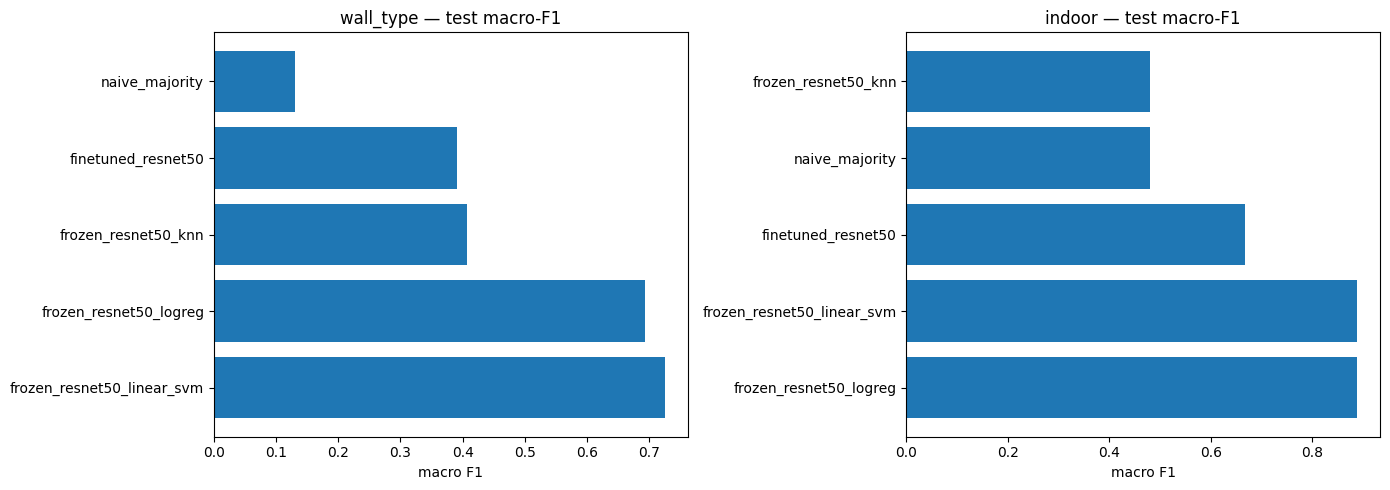

In [12]:
# ============================================================
# 11. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results).sort_values(["task", "macro_f1"], ascending=[True, False])
results_df.to_csv(os.path.join(OUTPUT_FOLDER, "resnet50_baseline_results.csv"), index=False)
display(results_df)

fig, axes = plt.subplots(1, len(TASKS), figsize=(7 * len(TASKS), 5))
for ax, task in zip(axes, TASKS):
    sub = results_df[results_df["task"] == task]
    ax.barh(sub["method"], sub["macro_f1"])
    ax.set_title(f"{task} — test macro-F1")
    ax.set_xlabel("macro F1")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "resnet50_baseline_comparison.png"), dpi=150)
plt.show()


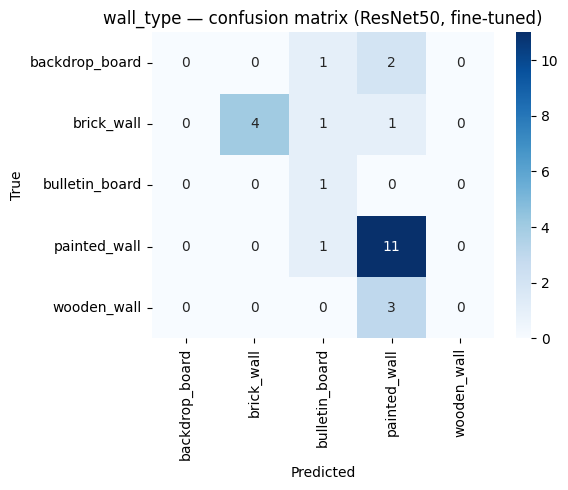


wall_type classification report (ResNet50, fine-tuned):
                precision    recall  f1-score   support

backdrop_board       0.00      0.00      0.00         3
    brick_wall       1.00      0.67      0.80         6
bulletin_board       0.25      1.00      0.40         1
  painted_wall       0.65      0.92      0.76        12
   wooden_wall       0.00      0.00      0.00         3

      accuracy                           0.64        25
     macro avg       0.38      0.52      0.39        25
  weighted avg       0.56      0.64      0.57        25



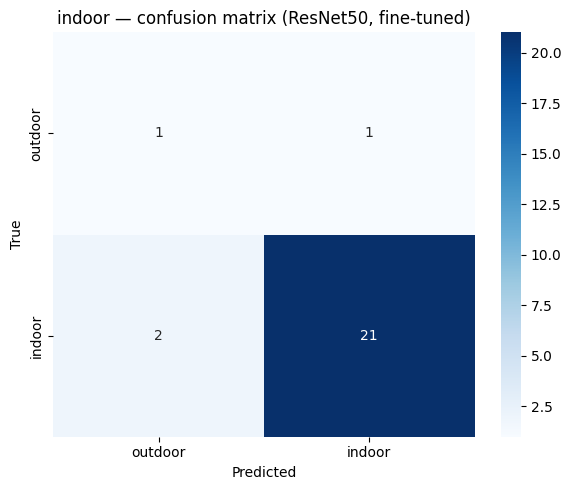


indoor classification report (ResNet50, fine-tuned):
              precision    recall  f1-score   support

     outdoor       0.33      0.50      0.40         2
      indoor       0.95      0.91      0.93        23

    accuracy                           0.88        25
   macro avg       0.64      0.71      0.67        25
weighted avg       0.90      0.88      0.89        25



In [13]:
# ============================================================
# 12. CONFUSION MATRIX FOR THE FINE-TUNED MODEL, PER TASK
# ============================================================

for task in TASKS:
    target_column = TARGET_COLUMN[task]
    model = finetuned_models[task]
    test_ds = WallDecorationDataset(test_df, target_column, transform=eval_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(DEVICE))
            all_preds.append(outputs.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    labels_display = WALL_TYPE_CLASSES if task == "wall_type" else ["outdoor", "indoor"]
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_display, yticklabels=labels_display, cmap="Blues")
    plt.title(f"{task} — confusion matrix (ResNet50, fine-tuned)")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, f"resnet50_confusion_matrix_{task}.png"), dpi=150)
    plt.show()

    print(f"\n{task} classification report (ResNet50, fine-tuned):")
    print(classification_report(all_labels, all_preds, target_names=[str(l) for l in labels_display], zero_division=0))


## GroupKFold cross-validation (recommended second number to report)

25 test images is a small, noisy sample. This reruns **frozen ResNet50 + Logistic Regression**
(cheap, no epochs) across 5 folds over train+val+test combined, respecting `group_id` so
near-duplicate images never leak across a fold's train/test split. Report the mean ± std
macro-F1 from this alongside the single-split test numbers above.


In [14]:
# ============================================================
# 13. GROUP K-FOLD CROSS-VALIDATION
# ============================================================

N_FOLDS = 5
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

cv_results = []
for task in TASKS:
    target_column_name = "wall_type" if task == "wall_type" else "indoor"
    # re-encode on the FULL pool for CV so no class is unseen within a fold
    if task == "wall_type":
        full_encoder = LabelEncoder().fit(full_df["wall_type"])
        full_df["wall_type_label"] = full_encoder.transform(full_df["wall_type"])
        target_column = "wall_type_label"
    else:
        target_column = "indoor"

    X_all, y_all = extract_features(resnet_extractor, full_df, target_column, BATCH_SIZE)
    groups = full_df["group_id"].values

    n_splits = min(N_FOLDS, pd.Series(groups).nunique())
    gkf = GroupKFold(n_splits=n_splits)
    fold_f1s = []
    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups), start=1):
        clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
        clf.fit(X_all[tr_idx], y_all[tr_idx])
        y_pred = clf.predict(X_all[te_idx])
        f1_macro = f1_score(y_all[te_idx], y_pred, average="macro", zero_division=0)
        fold_f1s.append(f1_macro)
        print(f"[{task}] fold {fold}/{n_splits} macro_f1={f1_macro:.3f}")

    cv_results.append({"task": task, "method": "frozen_resnet50_logreg_groupkfold",
                        "mean_macro_f1": np.mean(fold_f1s), "std_macro_f1": np.std(fold_f1s)})
    print(f"[{task}] {n_splits}-fold mean macro_f1 = {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}\n")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.to_csv(os.path.join(OUTPUT_FOLDER, "resnet50_groupkfold_results.csv"), index=False)
display(cv_results_df)


[wall_type] fold 1/5 macro_f1=0.422
[wall_type] fold 2/5 macro_f1=0.591
[wall_type] fold 3/5 macro_f1=0.532
[wall_type] fold 4/5 macro_f1=0.598
[wall_type] fold 5/5 macro_f1=0.716
[wall_type] 5-fold mean macro_f1 = 0.572 ± 0.096

[indoor] fold 1/5 macro_f1=0.606
[indoor] fold 2/5 macro_f1=0.858
[indoor] fold 3/5 macro_f1=0.920
[indoor] fold 4/5 macro_f1=0.892
[indoor] fold 5/5 macro_f1=0.816
[indoor] 5-fold mean macro_f1 = 0.818 ± 0.112



,task,method,mean_macro_f1,std_macro_f1
0,wall_type,frozen_resnet50_logreg_groupkfold,0.571797,0.095782
1,indoor,frozen_resnet50_logreg_groupkfold,0.818203,0.111850


## Outputs saved

Under `OUTPUT_FOLDER`:
- `resnet50_baseline_results.csv` — naive / frozen-feature / fine-tuned test metrics
- `resnet50_groupkfold_results.csv` — cross-validated macro-F1 (more robust estimate)
- `finetuned_resnet50_wall_type.pt`, `finetuned_resnet50_indoor.pt` — trained weights
- `resnet50_baseline_comparison.png`, `resnet50_confusion_matrix_<task>.png`
